In [1]:
import pandas as pd

In [2]:
import random

In [3]:
L = []
for i in range(10000):
  a = random.randint(1,6)
  b = random.randint(1,6)

  L.append(a + b)

In [4]:
len(L)

10000

In [5]:
L[:5]

[5, 5, 6, 7, 6]

In [6]:
s = (pd.Series(L).value_counts()/pd.Series(L).value_counts().sum()).sort_index()

In [7]:
s

2     0.0265
3     0.0608
4     0.0773
5     0.1075
6     0.1414
7     0.1696
8     0.1365
9     0.1131
10    0.0835
11    0.0549
12    0.0289
Name: count, dtype: float64

<Axes: >

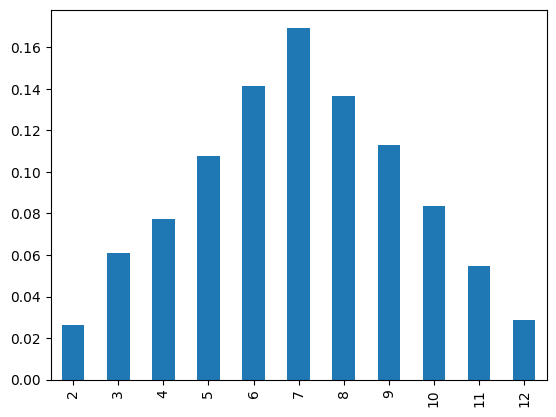

In [8]:
s.plot(kind='bar')

In [9]:
import numpy as np
np.cumsum(s)

2     0.0265
3     0.0873
4     0.1646
5     0.2721
6     0.4135
7     0.5831
8     0.7196
9     0.8327
10    0.9162
11    0.9711
12    1.0000
Name: count, dtype: float64

<Axes: >

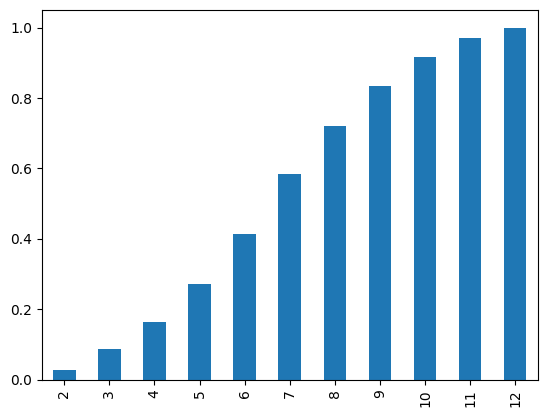

In [10]:
np.cumsum(s).plot(kind='bar')

# Parametric Density Estimation

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from numpy.random import normal

sample = normal(loc=50, scale=5,size=1000)

In [12]:
sample.mean()

np.float64(50.05478130648127)

(array([  2.,   9.,  40., 101., 222., 255., 220., 107.,  34.,  10.]),
 array([31.25869114, 34.68981213, 38.12093313, 41.55205412, 44.98317512,
        48.41429611, 51.84541711, 55.2765381 , 58.7076591 , 62.13878009,
        65.56990109]),
 <BarContainer object of 10 artists>)

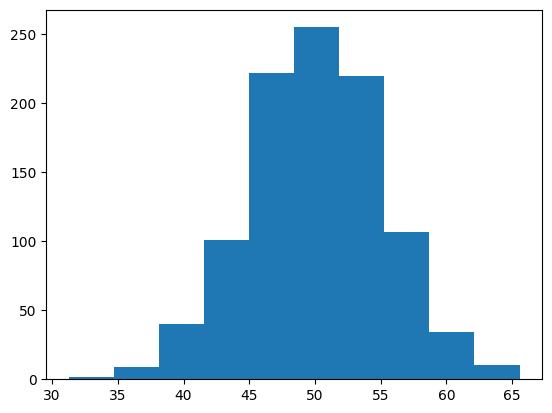

In [13]:
# plot histogram to understand the distribution of data
plt.hist(sample,bins=10)

In [14]:
# calculate sample mean and sample std dev
sample_mean = sample.mean()
sample_std = sample.std()

In [15]:
# fit the distribution with the above parameters

from scipy.stats import norm
dist = norm(sample_mean, sample_std)

In [16]:
values = np.linspace(sample.min(),sample.max(),100)

In [17]:
sample.max()

np.float64(65.56990108755946)

In [18]:
probabilities = [dist.pdf(value) for value in values]

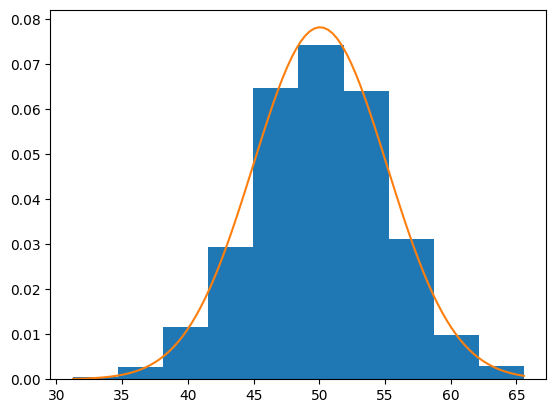

In [19]:
# plot the histogram and pdf
plt.hist(sample,bins=10,density=True)
plt.plot(values,probabilities)

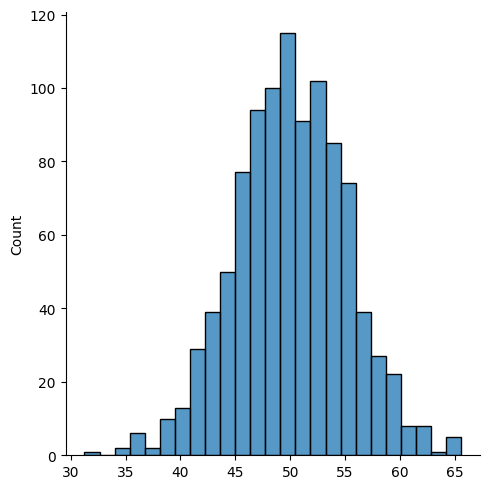

In [20]:
import seaborn as sns
sns.displot(sample)

# KDE

In [21]:
# generate a sample
sample1 = normal(loc=20, scale=5, size=300)
sample2 = normal(loc=40, scale=5, size=700)
sample = np.hstack((sample1, sample2))

In [22]:
sample

array([11.61234035, 22.83514004, 25.72357651, 16.57934446, 14.25463813,
       27.35615424, 25.88742514, 21.69950158, 16.02777556, 19.52995106,
       17.76408827, 15.23455598, 14.73011117, 27.03334513, 26.34976301,
       19.91225782, 19.78328419, 15.80767806, 27.90660535, 17.84963126,
       20.28529067, 13.73693412, 26.27927404, 19.19026674, 15.2654201 ,
       31.17731928, 25.93922487, 22.08112467, 20.32016559, 20.49650678,
       14.87510615, 20.49132504, 18.7746982 , 27.27298502, 28.32013542,
       20.09686944, 27.33766548, 14.44996664, 21.7174735 , 16.34763289,
       14.24221395, 20.60118358,  2.76984783, 18.16564857, 19.6804972 ,
       20.29812921, 26.84250551, 24.93721576, 12.98099462, 13.4899462 ,
       22.76837497, 19.52454155, 22.00820869, 21.84628766, 26.31483109,
       22.69834344, 17.25656507, 29.78178327, 12.47911154, 22.48391013,
       22.49154007, 15.05579594, 13.5326611 , 27.64545539, 24.75013115,
        5.88445878, 18.50252778, 28.02494916, 23.91315923, 26.17

(array([ 1.,  1.,  1.,  1.,  0.,  2.,  6.,  6.,  5.,  8., 19., 17., 12.,
        17., 18., 20., 29., 16., 33., 22., 14., 14., 15., 20., 10.,  7.,
        11., 22., 31., 17., 45., 44., 60., 47., 46., 61., 66., 50., 43.,
        37., 29., 26., 12., 15.,  5.,  7.,  5.,  3.,  3.,  1.]),
 array([ 2.76984783,  3.83025251,  4.89065719,  5.95106188,  7.01146656,
         8.07187124,  9.13227593, 10.19268061, 11.2530853 , 12.31348998,
        13.37389466, 14.43429935, 15.49470403, 16.55510871, 17.6155134 ,
        18.67591808, 19.73632277, 20.79672745, 21.85713213, 22.91753682,
        23.9779415 , 25.03834618, 26.09875087, 27.15915555, 28.21956024,
        29.27996492, 30.3403696 , 31.40077429, 32.46117897, 33.52158365,
        34.58198834, 35.64239302, 36.70279771, 37.76320239, 38.82360707,
        39.88401176, 40.94441644, 42.00482112, 43.06522581, 44.12563049,
        45.18603517, 46.24643986, 47.30684454, 48.36724923, 49.42765391,
        50.48805859, 51.54846328, 52.60886796, 53.66927264,

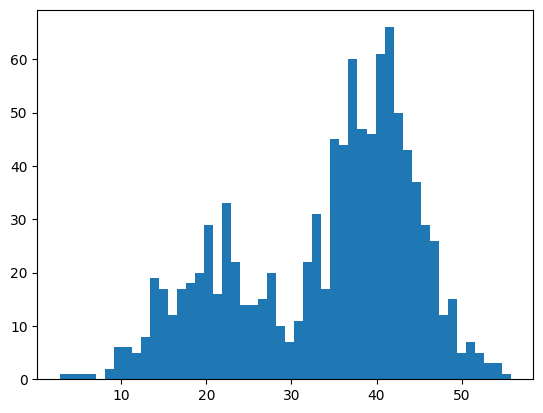

In [23]:
# plot histogram bins=50
plt.hist(sample,bins=50)

In [25]:
from sklearn.neighbors import KernelDensity

model = KernelDensity(bandwidth=5, kernel='gaussian')

# convert data to a 2D array
sample = sample.reshape((len(sample), 1))

model.fit(sample)

KernelDensity(bandwidth=5)

In [26]:
values = np.linspace(sample.min(),sample.max(),100)
values = values.reshape((len(values), 1))

In [27]:
probabilities = model.score_samples(values)
probabilities = np.exp(probabilities)

`score_samples(values)` returns the log-density estimate of the input samples values. This is because the `score_samples()` method of the KernelDensity class returns the logarithm of the probability density estimate rather than the actual probability density estimate.

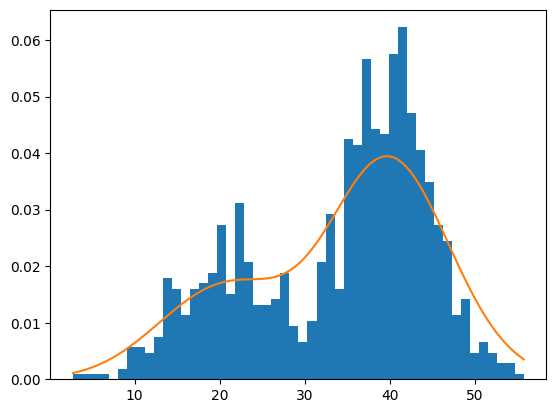

In [28]:
plt.hist(sample, bins=50, density=True)
plt.plot(values[:], probabilities)
plt.show()

<Axes: ylabel='Density'>

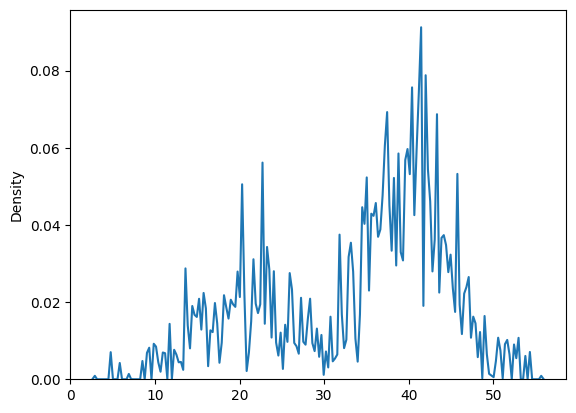

In [29]:
sns.kdeplot(sample.reshape(1000),bw_adjust=0.02)

In [30]:
import seaborn as sns

In [31]:
df = sns.load_dataset('iris')

In [32]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


<Axes: xlabel='sepal_length', ylabel='Density'>

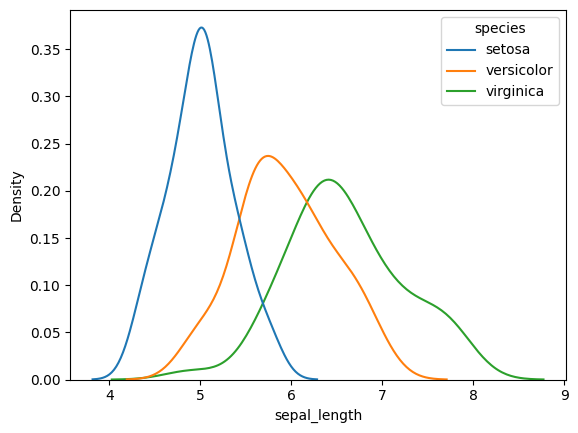

In [33]:
sns.kdeplot(data=df,x='sepal_length',hue='species')

<Axes: xlabel='sepal_width', ylabel='Density'>

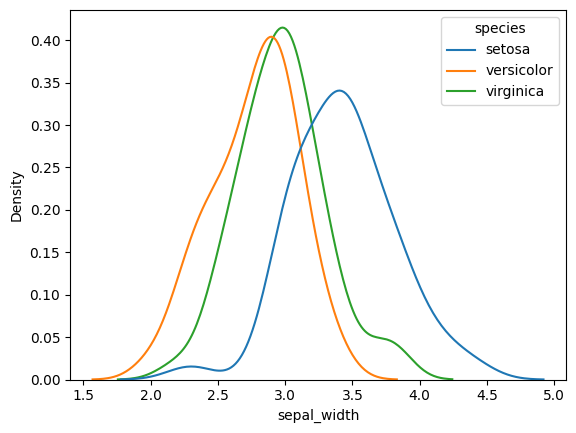

In [34]:
sns.kdeplot(data=df,x='sepal_width',hue='species')

<Axes: xlabel='petal_length', ylabel='Density'>

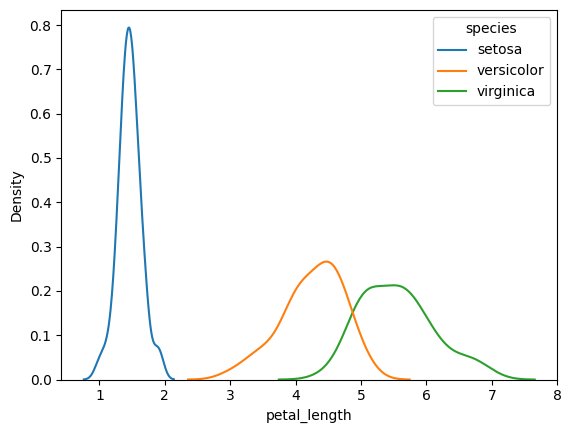

In [35]:
sns.kdeplot(data=df,x='petal_length',hue='species')

<Axes: xlabel='petal_width', ylabel='Density'>

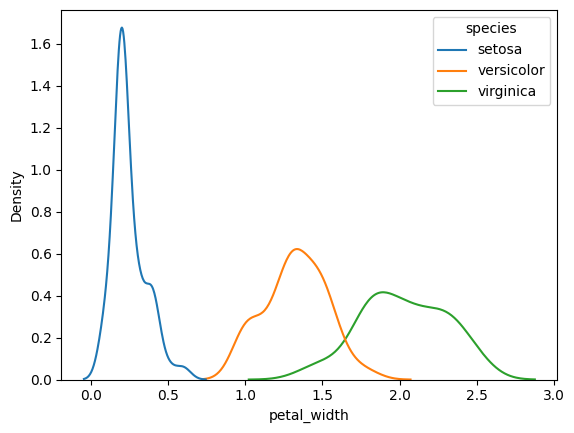

In [36]:
sns.kdeplot(data=df,x='petal_width',hue='species')

<Axes: xlabel='petal_width', ylabel='Density'>

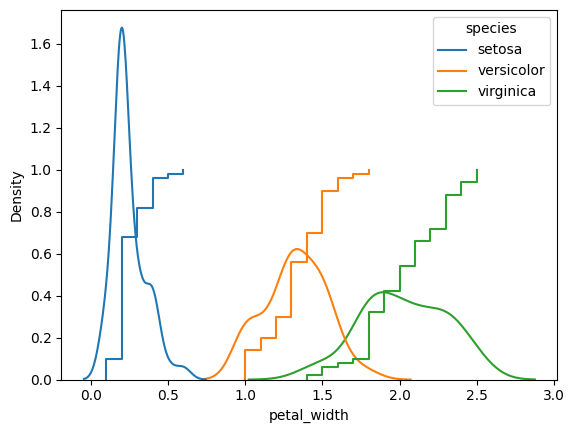

In [39]:
sns.kdeplot(data=df,x='petal_width',hue='species')
sns.ecdfplot(data=df,x='petal_width',hue='species')

In [40]:
titanic = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

In [41]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<Axes: xlabel='Age', ylabel='Density'>

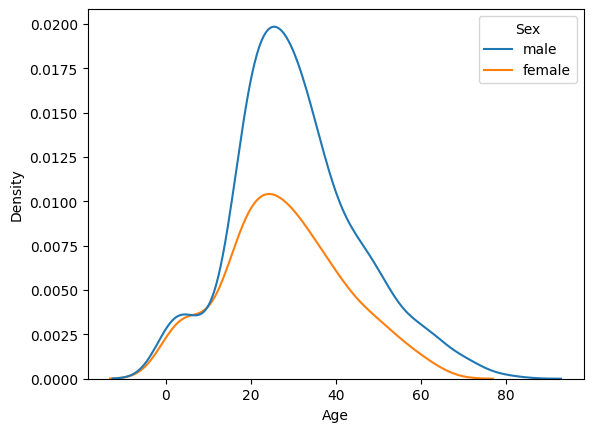

In [42]:
# code here
sns.kdeplot(data=titanic,x='Age',hue='Sex')

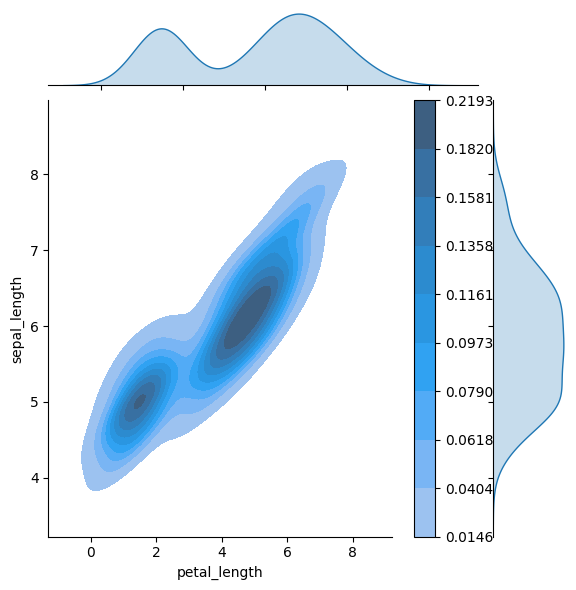

In [ ]:
sns.jointplot(data=df, x="petal_length", y="sepal_length", kind="kde",fill=True,cbar=True)

<Axes: xlabel='Age', ylabel='Density'>

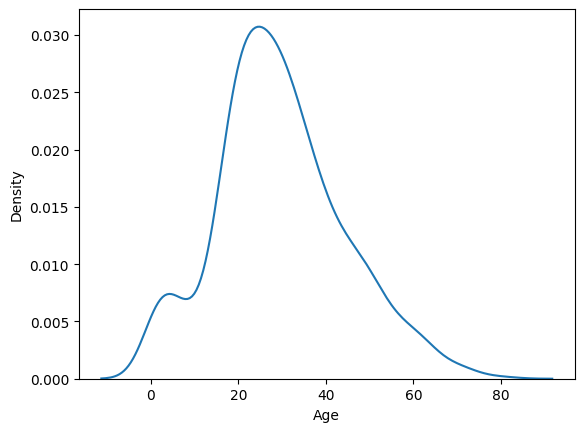

In [44]:
sns.kdeplot(titanic['Age'])

In [45]:
titanic['Age'].mean()

np.float64(29.69911764705882)

In [46]:
x = (titanic['Age'] - titanic['Age'].mean())/titanic['Age'].std()

<Axes: xlabel='Age', ylabel='Density'>

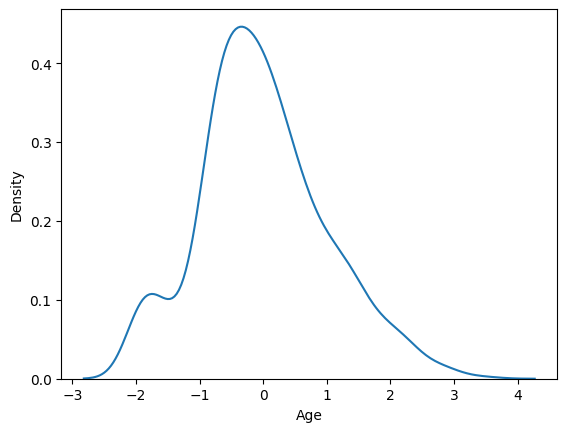

In [47]:
sns.kdeplot(x)

In [48]:
x.mean()

np.float64(2.338621049070358e-16)

In [49]:
x.std()

np.float64(1.0)

In [50]:
titanic['Age'].skew()

np.float64(0.38910778230082704)

In [51]:
titanic['Age'].mean() + 3*titanic['Age'].std()

np.float64(73.27860964406094)

In [52]:
titanic['Age'].mean() - 3*titanic['Age'].std()

np.float64(-13.880374349943303)

In [53]:
titanic[titanic['Age'] > 73]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
630,631,1,1,"Barkworth, Mr. Algernon Henry Wilson",male,80.0,0,0,27042,30.000,A23,S
851,852,0,3,"Svensson, Mr. Johan",male,74.0,0,0,347060,7.775,NaN,S


In [54]:
titanic['Age'].max()

np.float64(80.0)

### PDFs and CDFs

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [56]:
data=pd.read_csv('iris.csv')
data.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [57]:
data.rename(columns={'SepalLengthCm':'SL','SepalWidthCm':'SW','PetalLengthCm':'PL','PetalWidthCm':'PW'},inplace=True)

In [58]:
iris_setosa=data[data['Species']=='Iris-setosa']
iris_versicolor=data[data['Species']=='Iris-versicolor']
iris_virginica=data[data['Species']=='Iris-virginica']

In [59]:
count, bin_edges = np.histogram(iris_setosa['PL'], bins=10)

In [60]:
pdf = count/sum(count)
cdf = np.cumsum(pdf)

In [61]:
pdf

array([0.02, 0.02, 0.04, 0.14, 0.24, 0.28, 0.14, 0.08, 0.  , 0.04])

In [62]:
cdf

array([0.02, 0.04, 0.08, 0.22, 0.46, 0.74, 0.88, 0.96, 0.96, 1.  ])

### Central limit theorem

In [63]:
delivery = pd.read_csv('deliveries.csv')

In [64]:
runs = delivery.groupby('batsman').sum()['batsman_runs']

In [65]:
random_means = []
for i in range(1000):
    arr = np.random.choice(runs, size=50)
    random_means.append(arr.mean())


In [66]:
len(random_means)

1000

In [67]:
random_means = np.array(random_means)

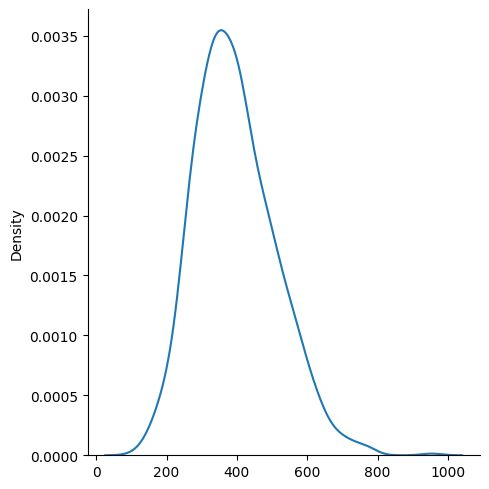

In [68]:
sns.displot(random_means, kind='kde')